# SETUP: `Iceland0_MARBL_2024`

This notebook configures the outermost ROMS grid and associated forcing files for the Iceland0_MARBL_2024 configuration.

- **Grid generation**: Build a coarse SRTM15-based grid and vertical coordinates using `roms_tools.Grid`.
- **Tides**: Generate TPXO-based tidal forcing files (`*_tides.nc`).
- **Surface forcing**: Create ERA5-based physical forcing and UNIFIED BGC surface climatologies.
- **Initial conditions**: Interpolate GLORYS + UNIFIED fields to the ROMS grid.
- **Boundaries**: Build GLORYS-based physical and UNIFIED BGC boundary forcing.
- **Child grid**: Define and save the nested Iceland1 grid and associated nesting metadata.

Run the notebook top-to-bottom when (re)creating the full set of input files for Iceland0.

# ROMS-TOOLS setup for Iceland0_MARBL_2024

First step is to set up the outer grid using ROMS-TOOLS and save the grid file.

In [1]:
import xarray as xr
from roms_tools import Grid

/home/x-uheede/.conda/envs/romstools-test/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
project='/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/'
datasets='/anvil/projects/x-ees250129/Datasets/'
model_name='Iceland0'
child_name='Iceland1'
grid_path='/anvil/projects/x-ees250129/x-uheede/MATLAB/setup_s2r_phys+bgc/1.Make_grid/Iceland0_grid_MAT.nc'

In [3]:
import dask

dask.config.set(
    scheduler="threads",  # Use multi-threading
    n_workers=10,  # Number of threads; adjust as needed
)

In [4]:
%%time

grid = Grid(
    nx=512,  # number of grid points in x-direction
    ny=512,  # number of grid points in y-direction
    size_x=1280,  # domain size in x-direction (in km)
    size_y=1280,  # domain size in y-direction (in km)
    center_lon=-25,  # longitude of the center of the domain
    center_lat=63,  # latitude of the center of the domain
    rot=-20,  # rotation of the grid (in degrees)
    topography_source={
        "name": "SRTM15",
        "path":datasets+"SRTM15/SRTM15_V2.6.nc"},
    N=60,  # number of vertical layers
    verbose=True,
)

2026-03-16 18:31:30 - INFO - === Creating the horizontal grid ===
2026-03-16 18:31:31 - INFO - Total time: 0.392 seconds
2026-03-16 18:31:31 - INFO - ================================================================================================
2026-03-16 18:31:31 - INFO - === Deriving the mask from coastlines ===
2026-03-16 18:31:31 - INFO - Total time: 0.660 seconds
2026-03-16 18:31:31 - INFO - ================================================================================================
2026-03-16 18:31:31 - INFO - === Generating the topography using SRTM15 data and hmin = 5.0 meters ===
2026-03-16 18:31:32 - INFO - Reading the topography data: 0.069 seconds
2026-03-16 18:31:32 - INFO - Regridding the topography: 0.176 seconds
2026-03-16 18:31:32 - INFO - Domain-wide topography smoothing: 0.030 seconds
2026-03-16 18:31:35 - INFO - Local topography smoothing: 2.751 seconds
2026-03-16 18:31:35 - INFO - Total time: 3.491 seconds
2026-03-16 18:31:35 - INFO - ========================

CPU times: user 4.28 s, sys: 215 ms, total: 4.5 s
Wall time: 4.58 s


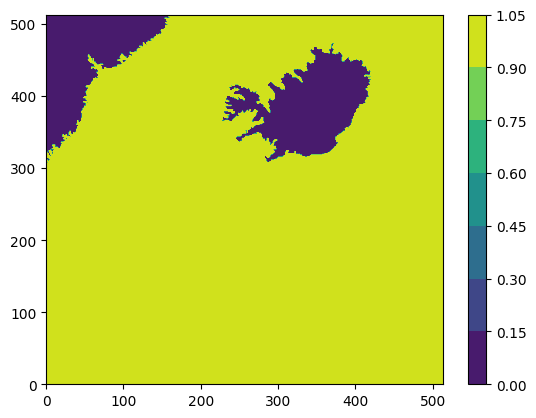

In [9]:
import matplotlib.pyplot as plt
cf=plt.contourf(grid.ds.mask_rho)
plt.colorbar(cf)

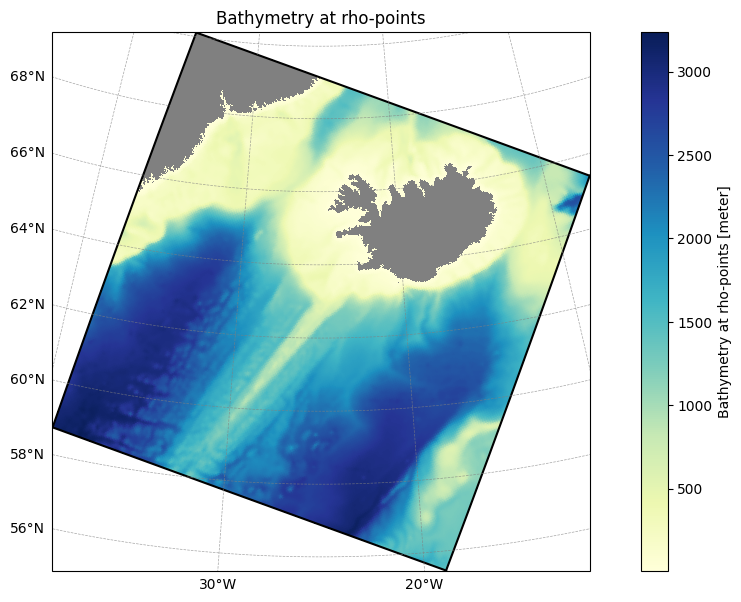

In [8]:
grid.plot()


In [20]:
filepath = project+model_name+'_grid.nc'

## Step 1: Grid Creation

Builds and writes the model grid file.

In [21]:
grid.save(filepath)

2025-10-03 14:57:16 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_grid.nc


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_grid.nc')]

In [22]:
tpxo_path = datasets+"TPXO/TPXO10.v2/"
tpxo_dict = {
    "grid": tpxo_path + "grid_tpxo10v2.nc",
    "h": tpxo_path + "h_tpxo10.v2.nc",
    "u": tpxo_path + "u_tpxo10.v2.nc",
}

Next, we set up tidal forcing:

In [23]:
from roms_tools import TidalForcing

In [5]:
from datetime import datetime

In [25]:
model_reference_date = datetime(2000, 1, 1)

In [26]:

tidal_forcing = TidalForcing(
    grid=grid,
    source={"name": "TPXO", "path": tpxo_dict},
    ntides=15,  # Number of constituents to consider <= 15. Default is 10.
    model_reference_date=model_reference_date,  # Model reference date. Default is January 1, 2000.
    use_dask=True
)

2025-10-03 14:57:20 - INFO - Applying 2D horizontal fill to the source data before regridding.
2025-10-03 14:57:23 - INFO - Applying 2D horizontal fill to the source data before regridding.
2025-10-03 14:57:23 - INFO - Applying 2D horizontal fill to the source data before regridding.
2025-10-03 14:57:24 - INFO - Applying 2D horizontal fill to the source data before regridding.


In [27]:
filepath = project+model_name+"_tides.nc"

## Step 2: Tidal Forcing Creation

Builds and writes the tidal forcing file.

In [28]:
%time tidal_forcing.save(filepath)

2025-10-03 14:57:25 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_tides.nc


[########################################] | 100% Completed | 7.69 ss
CPU times: user 3min 15s, sys: 1.28 s, total: 3min 17s
Wall time: 7.8 s


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_tides.nc')]

For the surface forcing, we use ERA5 plus the unified BGC dataset

In [29]:
from roms_tools import Grid, SurfaceForcing

In [30]:
start_time = datetime(2024, 1, 1)
end_time = datetime(2024, 6, 1)

In [31]:
surface_forcing_kwargs = {
    "grid": grid,
    "start_time": start_time,
    "end_time": end_time,
    "type": "physics",
    "model_reference_date": datetime(2000, 1, 1), # this is the default
}

In [32]:
%%time

surface_forcing = SurfaceForcing(
    **surface_forcing_kwargs,
    source={"name": "ERA5"},
    use_dask=True,
)

2025-10-03 14:57:33 - INFO - No path specified for ERA5 source; defaulting to ARCO ERA5 dataset on Google Cloud.
2025-10-03 14:59:11 - INFO - Data will be interpolated onto the grid coarsened by factor 2. Remember to set `interp_frc = 1` in your `bulk_frc.opt` ROMS option file.
2025-10-03 14:59:11 - INFO - Applying 2D horizontal fill to the source data before regridding.
2025-10-03 14:59:14 - INFO - Applying 2D horizontal fill to the source data before regridding.


CPU times: user 2min 59s, sys: 8.2 s, total: 3min 8s
Wall time: 2min 35s


[########################################] | 100% Completed | 303.47 ms


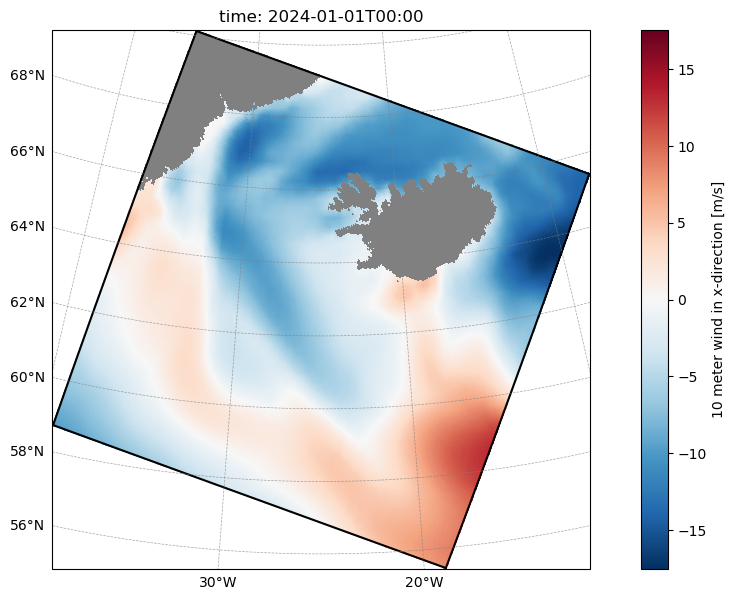

In [33]:
surface_forcing.plot("uwnd", time=0)

In [34]:
#cesm_bgc_path = "/global/cfs/projectdirs/m4746/Datasets/CESM_REGRIDDED/CESM-surface_lowres_regridded.nc"
unified_bgc_path = datasets+"UNIFIED/BGCdataset.nc"

In [35]:
%%time

unified_bgc_surface_forcing = SurfaceForcing(
    grid=grid,
    start_time=start_time,
    end_time=end_time,
    source={"name": "UNIFIED", "path": unified_bgc_path, "climatology": True},
    type="bgc",
    use_dask=True,
)

2025-10-03 15:00:12 - INFO - Data will be interpolated onto the grid coarsened by factor 2. Remember to set `interp_frc = 1` in your `bgc.opt` ROMS option file.
2025-10-03 15:00:12 - INFO - 2D horizontal fill is skipped because source data already contains filled values.


CPU times: user 142 ms, sys: 11 ms, total: 153 ms
Wall time: 301 ms


In [36]:
filepath = project+model_name+"_surface_forcing2024.nc"

## Step 3: Surface Forcing Creation

Builds and writes the physical surface forcing file.

In [37]:
%time surface_forcing.save(filepath)

2025-10-03 15:00:14 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_surface_forcing2024_202401.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_surface_forcing2024_202402.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_surface_forcing2024_202403.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_surface_forcing2024_202404.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_surface_forcing2024_202405.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_surface_forcing2024_202406.nc


[########################################] | 100% Completed | 147.59 s
[########################################] | 100% Completed | 139.10 s
[########################################] | 100% Completed | 162.77 s
[########################################] | 100% Completed | 155.81 s
[########################################] | 100% Completed | 158.63 s
[########################################] | 100% Completed | 519.49 ms
CPU times: user 5h 37min 35s, sys: 2min 16s, total: 5h 39min 52s
Wall time: 14min 4s


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_surface_forcing2024_202401.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_surface_forcing2024_202402.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_surface_forcing2024_202403.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_surface_forcing2024_202404.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_surface_forcing2024_202405.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_surface_forcing2024_202406.nc')]

In [38]:
filepath = project+model_name+"_bgc_surface_forcing.nc"

## Step 4: BGC Surface Forcing Creation

Builds and writes the biogeochemical surface forcing file.

In [39]:
%time unified_bgc_surface_forcing.save(filepath)

2025-10-03 15:14:16 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_bgc_surface_forcing_clim.nc


[########################################] | 100% Completed | 203.94 ms
CPU times: user 200 ms, sys: 10.8 ms, total: 211 ms
Wall time: 242 ms


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_bgc_surface_forcing_clim.nc')]

Next we generate the initial file

In [40]:
from roms_tools import Grid, InitialConditions

In [5]:
from datetime import datetime

In [42]:
ini_time = datetime(2024, 1, 5)

In [43]:
path = datasets+"GLORYS/ICELAND_DOMAIN/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-01-05_no_depth_zos.nc"

In [5]:
%%time

initial_conditions_with_unified_bgc = InitialConditions(
    grid=grid,
    ini_time=ini_time,
    source={"name": "GLORYS", "path": path},
    bgc_source={
        "name": "UNIFIED",
        "path": unified_bgc_path,
        "climatology": True,
    },  # bgc_source is optional
    model_reference_date=datetime(2000, 1, 1), # this is the default
    use_dask=True,
)

CPU times: user 10 μs, sys: 1 μs, total: 11 μs
Wall time: 17.4 μs


NameError: name 'InitialConditions' is not defined

In [45]:
filepath = project+model_name+"_initial_conditions.nc"

## Step 5: Initial Conditions Creation

Builds and writes the model initial conditions file.

In [46]:
%time initial_conditions_with_unified_bgc.save(filepath)

2025-10-03 15:14:33 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_initial_conditions.nc


[########################################] | 100% Completed | 190.02 s
CPU times: user 41min 19s, sys: 17min 23s, total: 58min 42s
Wall time: 3min 13s


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_initial_conditions.nc')]

In [6]:
#glorys_path = [
#    datasets+"/GLORYS/ICELAND_DOMAIN/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-*_no_depth_zos.nc"]

In [6]:
glorys_path = ['/anvil/projects/x-ees250129/cson-forge-data/source-data/GLORYS_GLOBAL/cmems_mod_glo_phy_my_0.083deg_P1D-m_GLOBAL_2024*.nc']
#glorys_path = ['/anvil/projects/x-ees250129/cson-forge-data/source-data/GLORYS_GLOBAL/*.nc']

In [48]:
#glorys_path = [
#    "/global/cfs/cdirs/m4632/uheede/GLORYS/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-01-04_no_depth_zos.nc",  # include data from day before start time
#    "/global/cfs/cdirs/m4632/uheede/GLORYS/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-01-05_no_depth_zos.nc",
#    "/global/cfs/cdirs/m4632/uheede/GLORYS/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-01-06_no_depth_zos.nc",
#    "/global/cfs/cdirs/m4632/uheede/GLORYS/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-01-07_no_depth_zos.nc",
#    "/global/cfs/cdirs/m4632/uheede/GLORYS/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-01-08_no_depth_zos.nc",
#    "/global/cfs/cdirs/m4632/uheede/GLORYS/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-01-09_no_depth_zos.nc",
#    "/global/cfs/cdirs/m4632/uheede/GLORYS/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-01-10_no_depth_zos.nc",
#    "/global/cfs/cdirs/m4632/uheede/GLORYS/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-01-11_no_depth_zos.nc",  # include data from day after end time
#    "/global/cfs/cdirs/m4632/uheede/GLORYS/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-01-12_no_depth_zos.nc", 
#    "/global/cfs/cdirs/m4632/uheede/GLORYS/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-01-13_no_depth_zos.nc", 
#    "/global/cfs/cdirs/m4632/uheede/GLORYS/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-01-14_no_depth_zos.nc",  # include data from day before start time
#    "/global/cfs/cdirs/m4632/uheede/GLORYS/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-01-15_no_depth_zos.nc",
#    "/global/cfs/cdirs/m4632/uheede/GLORYS/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-01-16_no_depth_zos.nc",
#    "/global/cfs/cdirs/m4632/uheede/GLORYS/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-01-17_no_depth_zos.nc",
#    "/global/cfs/cdirs/m4632/uheede/GLORYS/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-01-18_no_depth_zos.nc",
#    "/global/cfs/cdirs/m4632/uheede/GLORYS/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-01-19_no_depth_zos.nc",
#    "/global/cfs/cdirs/m4632/uheede/GLORYS/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-01-20_no_depth_zos.nc",
#    "/global/cfs/cdirs/m4632/uheede/GLORYS/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-01-21_no_depth_zos.nc",
#    "/global/cfs/cdirs/m4632/uheede/GLORYS/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-01-22_no_depth_zos.nc",
#    "/global/cfs/cdirs/m4632/uheede/GLORYS/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-01-23_no_depth_zos.nc",
#    "/global/cfs/cdirs/m4632/uheede/GLORYS/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-01-24_no_depth_zos.nc",  # include data from day before start time
#    "/global/cfs/cdirs/m4632/uheede/GLORYS/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-01-25_no_depth_zos.nc",
#    "/global/cfs/cdirs/m4632/uheede/GLORYS/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-01-26_no_depth_zos.nc",
#    "/global/cfs/cdirs/m4632/uheede/GLORYS/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-01-27_no_depth_zos.nc",
#    "/global/cfs/cdirs/m4632/uheede/GLORYS/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-01-28_no_depth_zos.nc",
#    "/global/cfs/cdirs/m4632/uheede/GLORYS/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-01-29_no_depth_zos.nc",
#    "/global/cfs/cdirs/m4632/uheede/GLORYS/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-01-30_no_depth_zos.nc",
#    #"/global/cfs/cdirs/m4632/uheede/GLORYS/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-01-31_no_depth_zos.nc"
#]

In [7]:
from roms_tools import Grid, BoundaryForcing

In [8]:
start_time = datetime(2024, 1, 1)
end_time = datetime(2024, 6, 30)

In [9]:
%%time

boundary_forcing = BoundaryForcing(
    grid=grid,
    start_time=start_time,
    end_time=end_time,
    boundaries={
        "south": True,
        "east": True,
        "north": True,  
        "west": True,
    },
    source={"name": "GLORYS", "path": glorys_path},
    type="physics",  # "physics" or "bgc"; default is "physics"
    model_reference_date=datetime(2000, 1, 1), # this is the default
    use_dask=True,
)

2026-03-12 18:01:45 - INFO - Using boundary configuration: {'south': True, 'east': True, 'north': True, 'west': True}
2026-03-12 18:01:45 - INFO - Loading full dataset and subsetting spatially (lazy operation)...
2026-03-12 18:02:06 - INFO - Processing 6 month(s) separately to reduce memory usage
2026-03-12 18:02:06 - INFO - Processing month 1/6: 2024-01


[########################################] | 100% Completed | 61.85 s


2026-03-12 18:03:21 - INFO - Processing month 2/6: 2024-02


[########################################] | 100% Completed | 51.50 s


2026-03-12 18:04:25 - INFO - Processing month 3/6: 2024-03


...

[########################################] | 100% Completed | 52.82 s


2026-03-12 18:06:38 - INFO - Processing month 5/6: 2024-05


[########################################] | 100% Completed | 54.93 s


2026-03-12 18:07:46 - INFO - Processing month 6/6: 2024-06


[########################################] | 100% Completed | 60.20 s
CPU times: user 34min 14s, sys: 27min 40s, total: 1h 1min 54s
Wall time: 7min 34s


In [17]:
boundary_forcing.ds.u_south

<xarray.DataArray 'u_south' (bry_time: 182, s_rho: 60, xi_u: 513)> Size: 22MB
dask.array<where, shape=(182, 60, 513), dtype=float32, chunksize=(1, 60, 513), chunktype=numpy.ndarray>
Coordinates:
    abs_time  (bry_time) datetime64[ns] 1kB 2024-01-01 2024-01-02 ... 2024-06-30
  * bry_time  (bry_time) float64 1kB 8.766e+03 8.767e+03 ... 8.946e+03 8.947e+03
Dimensions without coordinates: s_rho, xi_u
Attributes:
    long_name:  southern boundary u-flux component
    units:      m/s

In [52]:
%%time

unified_bgc_boundary_forcing = BoundaryForcing(
    grid=grid,
    start_time=start_time,
    end_time=end_time,
    boundaries={
        "south": True,
        "east": True,
        "north": True,  
        "west": True,
    },
    source={"name": "UNIFIED", "path": unified_bgc_path, "climatology": True},
    type="bgc",
    use_dask=True,
)

2025-10-03 15:18:53 - INFO - Sea surface height will NOT be used to adjust depth coordinates.


CPU times: user 6.56 s, sys: 140 ms, total: 6.7 s
Wall time: 6.89 s


## Step 6: BGC Boundary Forcing Creation

Builds and writes the biogeochemical boundary forcing file.

In [ ]:
filepath = project+model_name+"_bgc_boundary_forcing_2024.nc"
%time unified_bgc_boundary_forcing.save(filepath)


## Step 7: Boundary Forcing Creation

Builds and writes the physical boundary forcing file.

In [10]:
filepath = project+model_name+"_boundary_forcing_2024.nc"
%time boundary_forcing.save(filepath)

2026-03-12 18:09:20 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_boundary_forcing_2024_202401.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_boundary_forcing_2024_202402.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_boundary_forcing_2024_202403.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_boundary_forcing_2024_202404.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_boundary_forcing_2024_202405.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_boundary_forcing_2024_202406.nc


CPU times: user 185 ms, sys: 194 ms, total: 379 ms
Wall time: 538 ms


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_boundary_forcing_2024_202401.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_boundary_forcing_2024_202402.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_boundary_forcing_2024_202403.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_boundary_forcing_2024_202404.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_boundary_forcing_2024_202405.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_boundary_forcing_2024_202406.nc')]

In [7]:
import time
from datetime import datetime
from pathlib import Path
from roms_tools.datasets.lat_lon_datasets import GLORYSDataset
from roms_tools.setup.utils import get_target_coords
from roms_tools import Grid

target_coords = get_target_coords(grid)

# Create dataset instance (with post-processing disabled to avoid extra computations)
print("Loading dataset...")
start_load = time.time()
data = GLORYSDataset(
    filename='/anvil/projects/x-ees250129/cson-forge-data/source-data/GLORYS_GLOBAL/cmems_mod_glo_phy_my_0.083deg_P1D-m_GLOBAL_2024*.nc',
    start_time=datetime(2024, 1, 1),  # Adjust as needed
    end_time=datetime(2024, 12, 31),    # Adjust as needed
    apply_post_processing=False,  # Skip post-processing to isolate choose_subdomain timing
    use_dask=True,  # Set to True if you want to test with dask
)
load_time = time.time() - start_load
print(f"Dataset loaded in {load_time:.2f} seconds")
print(f"Dataset shape: {dict(data.ds.dims)}")

# Time the choose_subdomain operation
print("\nRunning choose_subdomain...")
start_subset = time.time()
data.choose_subdomain(
    target_coords,
    buffer_points=3,  # Adjust as needed
)
subset_time = time.time() - start_subset

print(f"\nResults:")
print(f"  choose_subdomain took: {subset_time:.2f} seconds")
print(f"  Subset shape: {dict(data.ds.dims)}")
print(f"  Original dataset size: {data.ds.nbytes / 1024**2:.2f} MB (if loaded)")

# Time loading/computing the subsetted data
print("\nLoading/computing subsetted data...")
start = time.time()
data.ds.load()  # This triggers actual computation with dask
load_time = time.time() - start
print(f"Loading subsetted data took: {load_time:.2f} seconds")

print(f"\nTotal time: {subset_time + load_time:.2f} seconds")
print(f"Subset shape: {dict(data.ds.dims)}")

Loading dataset...
Dataset loaded in 21.35 seconds
Dataset shape: {'time': 366, 'depth': 50, 'latitude': 2041, 'longitude': 4320}

Running choose_subdomain...

Results:
  choose_subdomain took: 0.02 seconds
  Subset shape: {'time': 366, 'depth': 50, 'latitude': 182, 'longitude': 393}
  Original dataset size: 40144.98 MB (if loaded)

Loading/computing subsetted data...


/tmp/ipykernel_3129609/1656603332.py:22: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Dataset shape: {dict(data.ds.dims)}")
/tmp/ipykernel_3129609/1656603332.py:35: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  Subset shape: {dict(data.ds.dims)}")


Loading subsetted data took: 601.55 seconds

Total time: 601.57 seconds
Subset shape: {'time': 366, 'depth': 50, 'latitude': 182, 'longitude': 393}


/tmp/ipykernel_3129609/1656603332.py:46: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Subset shape: {dict(data.ds.dims)}")


In [8]:
# Create dataset instance (with post-processing disabled to avoid extra computations)
print("Loading dataset...")
start_load = time.time()
data = GLORYSDataset(
    filename=datasets+"/GLORYS/ICELAND_DOMAIN/2024/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_52.50W-2.67E_44.33N-74.42N_1.54-3992.48m_2024-*_no_depth_zos.nc",
    start_time=datetime(2024, 1, 1),  # Adjust as needed
    end_time=datetime(2024, 12, 31),    # Adjust as needed
    apply_post_processing=False,  # Skip post-processing to isolate choose_subdomain timing
    use_dask=True,  # Set to True if you want to test with dask
)
load_time = time.time() - start_load
print(f"Dataset loaded in {load_time:.2f} seconds")
print(f"Dataset shape: {dict(data.ds.dims)}")

# Time the choose_subdomain operation
print("\nRunning choose_subdomain...")
start_subset = time.time()
data.choose_subdomain(
    target_coords,
    buffer_points=3,  # Adjust as needed
)
subset_time = time.time() - start_subset

print(f"\nResults:")
print(f"  choose_subdomain took: {subset_time:.2f} seconds")
print(f"  Subset shape: {dict(data.ds.dims)}")
print(f"  Original dataset size: {data.ds.nbytes / 1024**2:.2f} MB (if loaded)")

# Time loading/computing the subsetted data
print("\nLoading/computing subsetted data...")
start = time.time()
data.ds.load()  # This triggers actual computation with dask
load_time = time.time() - start
print(f"Loading subsetted data took: {load_time:.2f} seconds")

print(f"\nTotal time: {subset_time + load_time:.2f} seconds")
print(f"Subset shape: {dict(data.ds.dims)}")

Loading dataset...


2026-03-12 17:03:52 - WARNING - No records found at or after the end_time: 2024-12-31 00:00:00.
/tmp/ipykernel_3129609/1034986288.py:13: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Dataset shape: {dict(data.ds.dims)}")
/tmp/ipykernel_3129609/1034986288.py:26: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  Subset shape: {dict(data.ds.dims)}")


Dataset loaded in 107.15 seconds
Dataset shape: {'time': 335, 'depth': 45, 'latitude': 362, 'longitude': 663}

Running choose_subdomain...

Results:
  choose_subdomain took: 0.02 seconds
  Subset shape: {'time': 335, 'depth': 45, 'latitude': 182, 'longitude': 393}
  Original dataset size: 16544.27 MB (if loaded)

Loading/computing subsetted data...
Loading subsetted data took: 323.27 seconds

Total time: 323.28 seconds
Subset shape: {'time': 335, 'depth': 45, 'latitude': 182, 'longitude': 393}


/tmp/ipykernel_3129609/1034986288.py:37: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Subset shape: {dict(data.ds.dims)}")


In [4]:
from roms_tools import Grid, ChildGrid

In [5]:
parent_grid = grid

In [11]:
child_grid_parameters = {
    "nx": 512,
    "ny": 384,
    "size_x": 384,
    "size_y": 288,
    "center_lon": -22.6,
    "center_lat": 63.55,
    "rot": 0,
    "mask_shapefile": datasets+"GSHHS/gshhg-shp-2.3.7/GSHHS_shp/f/GSHHS_f_L1.shp",
    "topography_source": {
        "name": "SRTM15",
        "path": datasets+"SRTM15/SRTM15_V2.6.nc"},
    "N":60  # number of vertical layers
}

%%time



UsageError: Line magic function `%%time` not found.


In [ ]:
child_grid = ChildGrid(
    **child_grid_parameters,
    parent_grid=parent_grid,
    boundaries={
        "south": True,
        "east": True,
        "north": True,
        "west": True,
    },  # this is the default
    metadata={"prefix": "child", "period": 1800.0}  # this is the default
)

In [ ]:
child_grid.plot_nesting(with_dim_names=True)

## Step 8: Child Grid Creation

Builds and writes the child grid file.

In [60]:
filepath = project+child_name+"_grid.nc"
child_grid.save(filepath=filepath)

2025-10-03 15:24:34 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland1_grid.nc


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland1_grid.nc')]

In [61]:
filepath_nesting = project+child_name+"_edata.nc"

In [62]:
child_grid.save_nesting(filepath=filepath_nesting)

2025-10-03 15:24:34 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland1_edata.nc


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland1_edata.nc')]